In [43]:
import pandas as pd
import os

# Define the path to your hosp folder
HOSP_PATH = 'data/hosp'

# Sepsis DRG Codes (870: w MCC, 871: w CC, 872: w/o CC/MCC)
SEPSIS_DRGS = ['870', '871', '872']

In [45]:
# 1. Pull the Sepsis Billing Cohort (Corrected for Data Types)
SEPSIS_DRGS = ['870', '871', '872']

drg_chunks = pd.read_csv(os.path.join(HOSP_PATH, 'drgcodes.csv'), chunksize=100000)

sepsis_billing_list = []
for chunk in drg_chunks:
    # Convert to string and strip spaces to ensure a match
    chunk['drg_code'] = chunk['drg_code'].astype(str).str.strip()
    filtered_chunk = chunk[chunk['drg_code'].isin(SEPSIS_DRGS)]
    sepsis_billing_list.append(filtered_chunk)

sepsis_billing = pd.concat(sepsis_billing_list)

print(f"Total Sepsis Billed Hospitalizations: {len(sepsis_billing)}")

Total Sepsis Billed Hospitalizations: 8792


In [47]:
# List of critical labs for SOFA calculation
# ItemIDs: 50912 (Creatinine), 50813 (Lactate), 50885 (Bilirubin)
SOFA_LABS = [50912, 50813, 50885, 51265]

# Process labs in chunks to save memory
lab_chunks = pd.read_csv(os.path.join(HOSP_PATH, 'labevents.csv'), chunksize=500000)
sepsis_labs = pd.concat([chunk[chunk['hadm_id'].isin(sepsis_billing['hadm_id']) & chunk['itemid'].isin(SOFA_LABS)] for chunk in lab_chunks])

# Calculate max/min values for each patient stay to act as ML features
features = sepsis_labs.groupby(['hadm_id', 'itemid'])['valuenum'].max().unstack()
features.columns = ['Bilirubin_Max', 'Lactate_Max', 'Creatinine_Max', 'Platelets_Min']

# Merge with your billing cohort
df_ml = pd.merge(sepsis_billing, features, on='hadm_id', how='left')

# Define "High Denial Risk" (Audit Risk)
# If Billed as Sepsis but no high lactate (>2.0) or high creatinine (>1.2)
df_ml['is_high_risk'] = ((df_ml['Lactate_Max'] < 2.0) & (df_ml['Creatinine_Max'] < 1.2)).astype(int)

print(f"Total High Risk Claims identified: {df_ml['is_high_risk'].sum()}")

Total High Risk Claims identified: 2270


In [23]:
# 1. Fetch Admissions data for Insurance and Age features
adm_chunks = pd.read_csv(os.path.join(HOSP_PATH, 'admissions.csv'), chunksize=500000)
admissions = pd.concat([chunk[chunk['hadm_id'].isin(df_ml['hadm_id'])] for chunk in adm_chunks])

# Merge back into our main ML dataframe
df_final = pd.merge(df_ml, admissions[['hadm_id', 'insurance', 'admission_type']], on='hadm_id', how='left')

# 2. Handle Missing Values (Crucial for Healthcare Data)
# Many patients might miss specific labs; we fill with the median to avoid bias
df_final[['Bilirubin_Max', 'Lactate_Max', 'Creatinine_Max', 'Platelets_Min']] = \
    df_final[['Bilirubin_Max', 'Lactate_Max', 'Creatinine_Max', 'Platelets_Min']].fillna(df_final.median(numeric_only=True))

# 3. Encode Categorical Data
df_final = pd.get_dummies(df_final, columns=['insurance', 'admission_type'], drop_first=True)

# Select features for the model
X = df_final.drop(columns=['subject_id', 'hadm_id', 'drg_code', 'description', 'drg_type', 'is_high_risk'])
y = df_final['is_high_risk']

In [49]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f}")

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1324
           1       0.99      0.94      0.96       435

    accuracy                           0.98      1759
   macro avg       0.98      0.97      0.97      1759
weighted avg       0.98      0.98      0.98      1759

ROC-AUC Score: 1.00


/opt/anaconda3/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [15:00:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


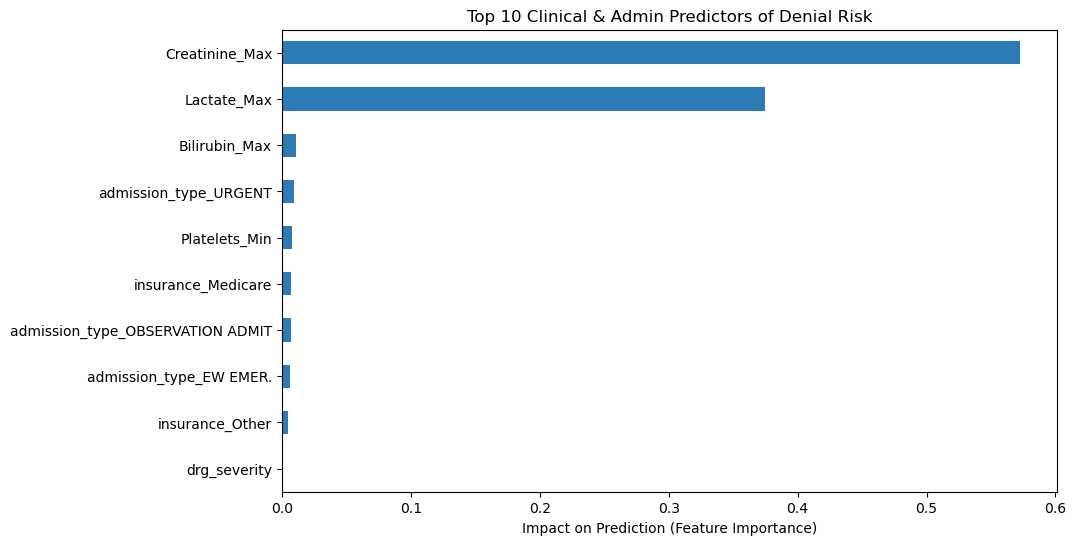

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the use_label_encoder warning for future runs:
# model = XGBClassifier(eval_metric='logloss') (already handled in my previous code)

plt.figure(figsize=(10,6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#2c7bb6')
plt.title('Top 10 Clinical & Admin Predictors of Denial Risk')
plt.xlabel('Impact on Prediction (Feature Importance)')
plt.gca().invert_yaxis() 
plt.show()

In [53]:
# 1. Define the columns that cause leakage (the ones used to create the label)
leakage_cols = ['Lactate_Max', 'Creatinine_Max']

# 2. Drop them from your Feature set X
X_blind = X.drop(columns=leakage_cols)

# 3. Re-split the data
X_train_b, X_test_b, y_train, y_test = train_test_split(X_blind, y, test_size=0.2, random_state=42)

# 4. Re-train the model
model_real = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss')
model_real.fit(X_train_b, y_train)

# 5. Re-evaluate
y_pred_b = model_real.predict(X_test_b)
print("--- NEW RESULTS (WITHOUT LEAKAGE) ---")
print(classification_report(y_test, y_pred_b))
print(f"Realistic ROC-AUC Score: {roc_auc_score(y_test, model_real.predict_proba(X_test_b)[:, 1]):.2f}")

--- NEW RESULTS (WITHOUT LEAKAGE) ---
              precision    recall  f1-score   support

           0       0.76      0.99      0.86      1324
           1       0.41      0.03      0.05       435

    accuracy                           0.75      1759
   macro avg       0.58      0.51      0.45      1759
weighted avg       0.67      0.75      0.66      1759

Realistic ROC-AUC Score: 0.62


In [55]:
# 1. Ensure admittime and dischtime are in the final dataframe
# We merge from the admissions dataframe we created earlier
df_final = pd.merge(df_final, admissions[['hadm_id', 'admittime', 'dischtime']], on='hadm_id', how='left', suffixes=('', '_drop'))

# Remove any duplicate columns if they existed
df_final = df_final.loc[:,~df_final.columns.duplicated()]

# 2. Now calculate Length of Stay (LOS)
df_final['admittime'] = pd.to_datetime(df_final['admittime'])
df_final['dischtime'] = pd.to_datetime(df_final['dischtime'])
df_final['los_days'] = (df_final['dischtime'] - df_final['admittime']).dt.total_seconds() / 86400

# 3. Re-define features (excluding the leakage labs)
# Check which dummy columns were actually created in your previous step
insurance_cols = [c for c in df_final.columns if 'insurance_' in c]
admission_cols = [c for c in df_final.columns if 'admission_type_' in c]

features_to_use = ['Bilirubin_Max', 'Platelets_Min', 'los_days'] + insurance_cols + admission_cols

# 4. Handle Imbalance & Train
X_enhanced = df_final[features_to_use].fillna(df_final.median(numeric_only=True))
y = df_final['is_high_risk']

# Calculate ratio for scale_pos_weight
ratio = len(y[y==0]) / len(y[y==1])

X_train_e, X_test_e, y_train, y_test = train_test_split(X_enhanced, y, test_size=0.2, random_state=42)

model_enhanced = XGBClassifier(
    n_estimators=100, 
    scale_pos_weight=ratio, # Balances the rare 'High Risk' cases
    learning_rate=0.05, 
    max_depth=6, 
    eval_metric='logloss'
)

model_enhanced.fit(X_train_e, y_train)

# 5. Evaluate
y_pred_e = model_enhanced.predict(X_test_e)
print("--- ENHANCED RCM MODEL RESULTS ---")
print(classification_report(y_test, y_pred_e))
print(f"Enhanced ROC-AUC: {roc_auc_score(y_test, model_enhanced.predict_proba(X_test_e)[:, 1]):.2f}")

--- ENHANCED RCM MODEL RESULTS ---
              precision    recall  f1-score   support

           0       0.82      0.56      0.67      1324
           1       0.32      0.62      0.42       435

    accuracy                           0.58      1759
   macro avg       0.57      0.59      0.54      1759
weighted avg       0.69      0.58      0.61      1759

Enhanced ROC-AUC: 0.63


In [37]:
# 1. Add Length of Stay (LOS) in days
df_final['admittime'] = pd.to_datetime(df_final['admittime'])
df_final['dischtime'] = pd.to_datetime(df_final['dischtime'])
df_final['los_days'] = (df_final['dischtime'] - df_final['admittime']).dt.total_seconds() / 86400

# 2. Re-select features, keeping Bilirubin and Platelets (but NOT Lactate/Creatinine)
features_to_keep = [
    'Bilirubin_Max', 'Platelets_Min', 'los_days',
    'insurance_Medicare', 'insurance_Other', 'insurance_Private',
    'admission_type_EU OBSERVATION', 'admission_type_EW EMER.', 
    'admission_type_OBSERVATION ADMIT', 'admission_type_URGENT'
]

# Ensure we only use columns that actually exist in your dataframe
existing_features = [c for c in features_to_keep if c in df_final.columns]
X_enhanced = df_final[existing_features].fillna(df_final.median(numeric_only=True))

# 3. Use "Scale_Pos_Weight" to handle the imbalance (Critical for RCM)
# This tells XGBoost to pay more attention to the minority 'High Risk' class
ratio = len(y[y==0]) / len(y[y==1])

X_train_e, X_test_e, y_train, y_test = train_test_split(X_enhanced, y, test_size=0.2, random_state=42)

model_enhanced = XGBClassifier(
    n_estimators=100, 
    scale_pos_weight=ratio, # <--- The "Secret Sauce" for imbalanced RCM data
    learning_rate=0.05, 
    max_depth=6, 
    eval_metric='logloss'
)

model_enhanced.fit(X_train_e, y_train)

# 4. Final Evaluation
y_pred_e = model_enhanced.predict(X_test_e)
print(classification_report(y_test, y_pred_e))
print(f"Enhanced ROC-AUC Score: {roc_auc_score(y_test, model_enhanced.predict_proba(X_test_e)[:, 1]):.2f}")

              precision    recall  f1-score   support

           0       0.82      0.56      0.67      1324
           1       0.32      0.62      0.42       435

    accuracy                           0.58      1759
   macro avg       0.57      0.59      0.54      1759
weighted avg       0.69      0.58      0.61      1759

Enhanced ROC-AUC Score: 0.63


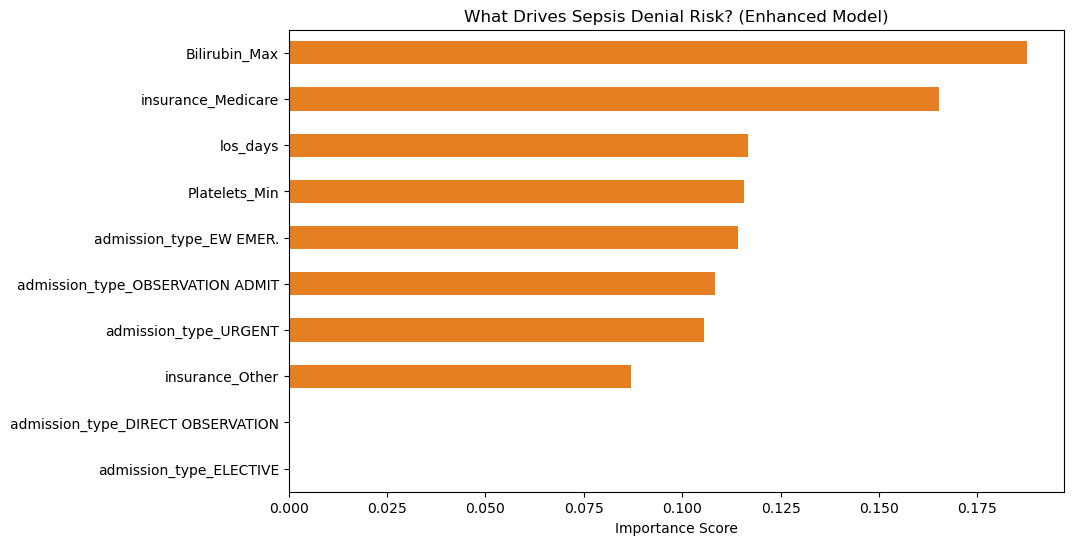

Total Claims Flagged for Review: 847
Potential Revenue at Risk Identified: $4,235,000


In [57]:
import matplotlib.pyplot as plt

# 1. Feature Importance
plt.figure(figsize=(10,6))
feat_importances = pd.Series(model_enhanced.feature_importances_, index=X_enhanced.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#e67e22')
plt.title('What Drives Sepsis Denial Risk? (Enhanced Model)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

# 2. Financial Simulation
total_high_risk_caught = (y_pred_e == 1).sum()
# Assume a Sepsis-3 clinical denial costs the hospital $5,000 in lost revenue
potential_savings = total_high_risk_caught * 5000 

print(f"Total Claims Flagged for Review: {total_high_risk_caught}")
print(f"Potential Revenue at Risk Identified: ${potential_savings:,}")